In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
data.dropna(inplace=True);
data.info()


<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
from sklearn.model_selection import train_test_split
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20433, dtype: float64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [6]:
train_data = X_train.join(y_train)

In [7]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20276,-119.21,34.19,15.0,5614.0,989.0,2754.0,994.0,5.0350,NEAR OCEAN,242900.0
18135,-122.01,37.35,33.0,2517.0,496.0,1158.0,443.0,5.0785,<1H OCEAN,289500.0
17795,-121.81,37.39,34.0,2218.0,286.0,827.0,299.0,7.4559,<1H OCEAN,456500.0
11950,-117.44,33.94,30.0,2992.0,516.0,1521.0,507.0,3.9128,INLAND,126900.0
12070,-117.60,33.85,9.0,6538.0,955.0,2928.0,892.0,5.3006,<1H OCEAN,221400.0
...,...,...,...,...,...,...,...,...,...,...
935,-122.04,37.50,17.0,407.0,97.0,307.0,100.0,3.1696,NEAR BAY,156300.0
15706,-122.42,37.79,6.0,670.0,301.0,655.0,284.0,3.4423,NEAR BAY,117500.0
746,-122.09,37.67,39.0,2069.0,500.0,1408.0,478.0,3.1115,NEAR BAY,153500.0
17349,-120.43,34.90,27.0,2019.0,354.0,1029.0,346.0,3.5391,<1H OCEAN,144700.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

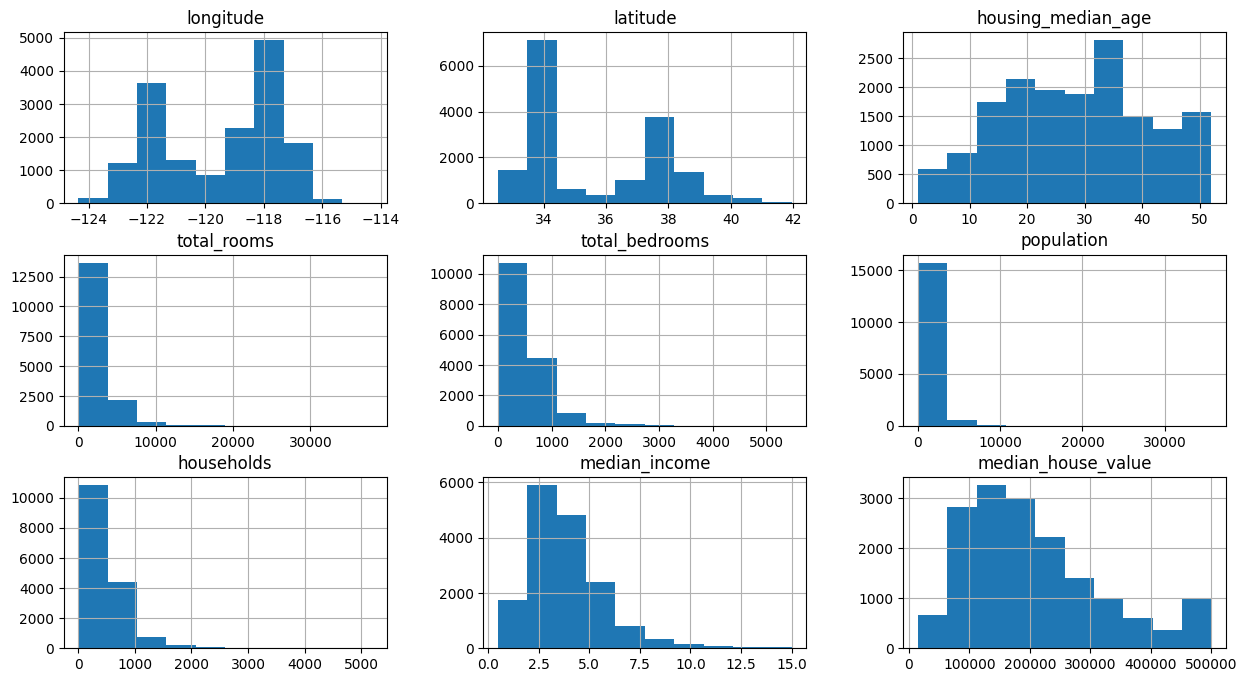

In [8]:
train_data.hist(figsize=(15,8))

<Axes: >

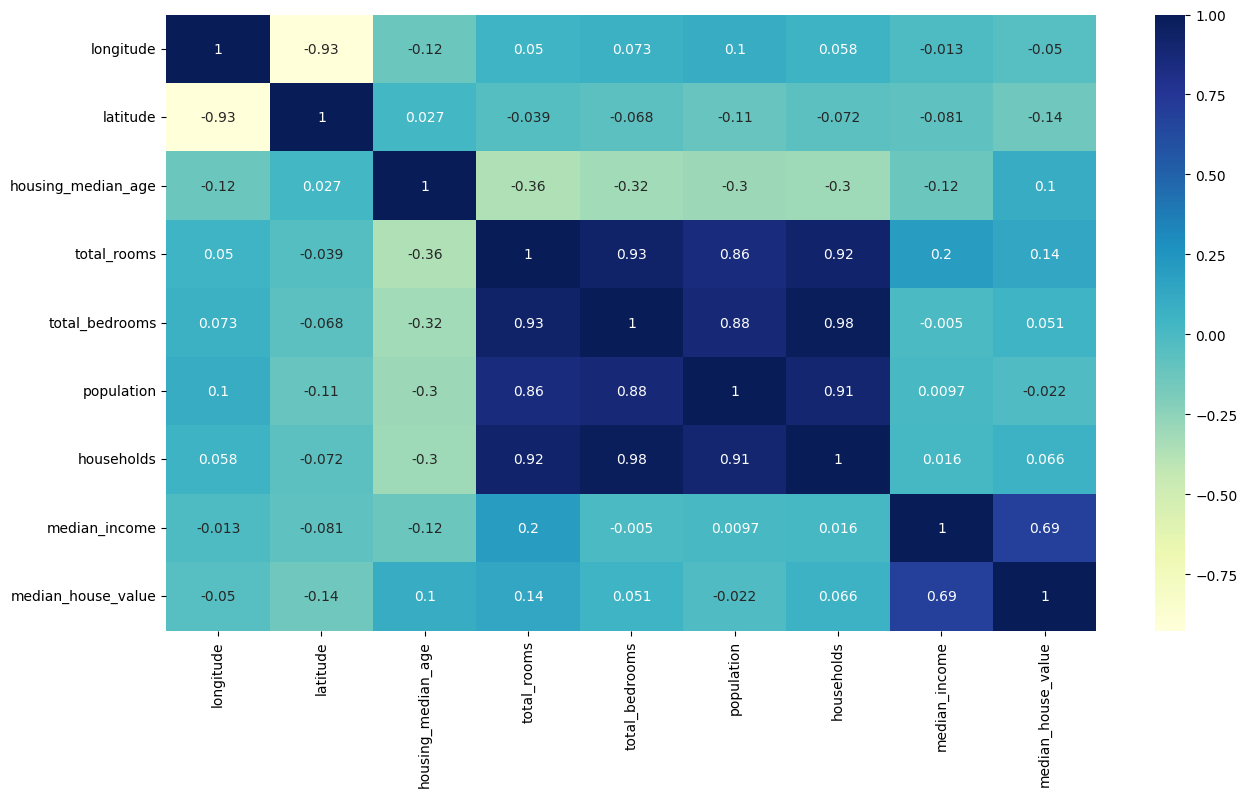

In [9]:
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")


In [10]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

In [11]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20276,-119.21,34.19,15.0,8.633197,6.897705,7.921173,6.902743,5.0350,NEAR OCEAN,242900.0
18135,-122.01,37.35,33.0,7.831220,6.208590,7.055313,6.095825,5.0785,<1H OCEAN,289500.0
17795,-121.81,37.39,34.0,7.704812,5.659482,6.719013,5.703782,7.4559,<1H OCEAN,456500.0
11950,-117.44,33.94,30.0,8.004032,6.248043,7.327781,6.230481,3.9128,INLAND,126900.0
12070,-117.60,33.85,9.0,8.785540,6.862758,7.982416,6.794587,5.3006,<1H OCEAN,221400.0
...,...,...,...,...,...,...,...,...,...,...
935,-122.04,37.50,17.0,6.011267,4.584967,5.730100,4.615121,3.1696,NEAR BAY,156300.0
15706,-122.42,37.79,6.0,6.508769,5.710427,6.486161,5.652489,3.4423,NEAR BAY,117500.0
746,-122.09,37.67,39.0,7.635304,6.216606,7.250636,6.171701,3.1115,NEAR BAY,153500.0
17349,-120.43,34.90,27.0,7.610853,5.872118,6.937314,5.849325,3.5391,<1H OCEAN,144700.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

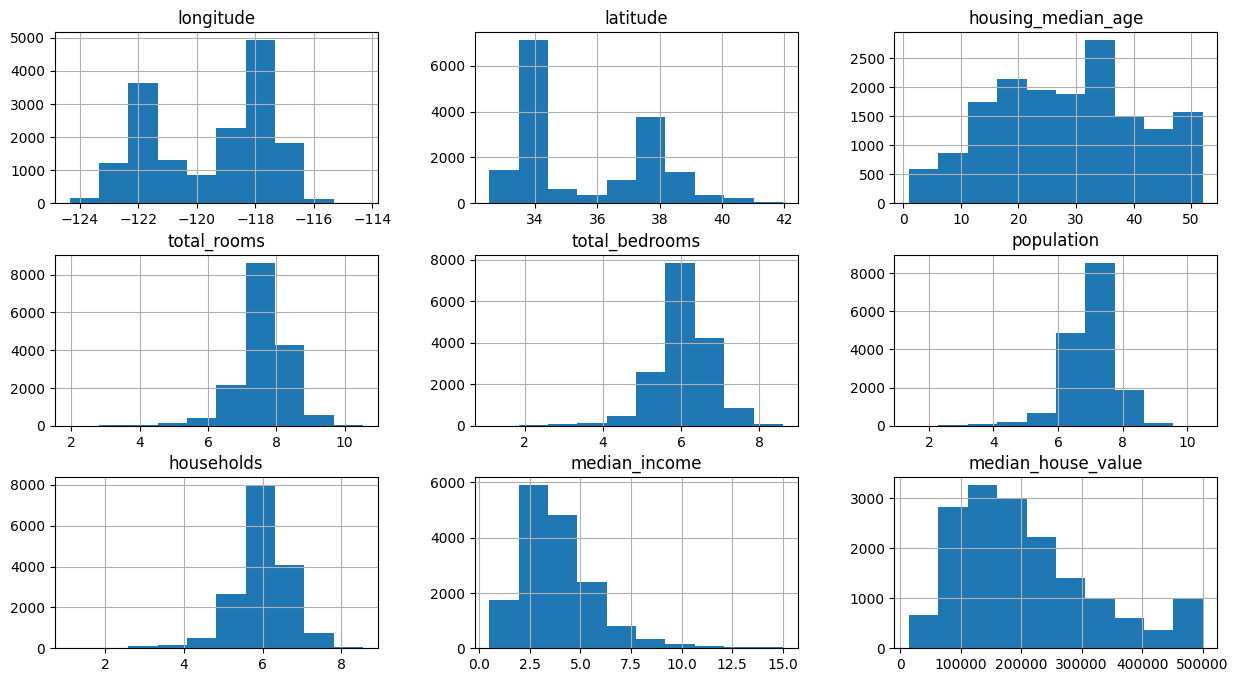

In [12]:
train_data.hist(figsize=(15,8))

In [13]:
train_data = train_data.join(
    pd.get_dummies(train_data.ocean_proximity, dtype=int)
).drop(['ocean_proximity'], axis=1)

In [14]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
20276,-119.21,34.19,15.0,8.633197,6.897705,7.921173,6.902743,5.0350,242900.0,0,0,0,0,1
18135,-122.01,37.35,33.0,7.831220,6.208590,7.055313,6.095825,5.0785,289500.0,1,0,0,0,0
17795,-121.81,37.39,34.0,7.704812,5.659482,6.719013,5.703782,7.4559,456500.0,1,0,0,0,0
11950,-117.44,33.94,30.0,8.004032,6.248043,7.327781,6.230481,3.9128,126900.0,0,1,0,0,0
12070,-117.60,33.85,9.0,8.785540,6.862758,7.982416,6.794587,5.3006,221400.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,-122.04,37.50,17.0,6.011267,4.584967,5.730100,4.615121,3.1696,156300.0,0,0,0,1,0
15706,-122.42,37.79,6.0,6.508769,5.710427,6.486161,5.652489,3.4423,117500.0,0,0,0,1,0
746,-122.09,37.67,39.0,7.635304,6.216606,7.250636,6.171701,3.1115,153500.0,0,0,0,1,0
17349,-120.43,34.90,27.0,7.610853,5.872118,6.937314,5.849325,3.5391,144700.0,1,0,0,0,0


<Axes: >

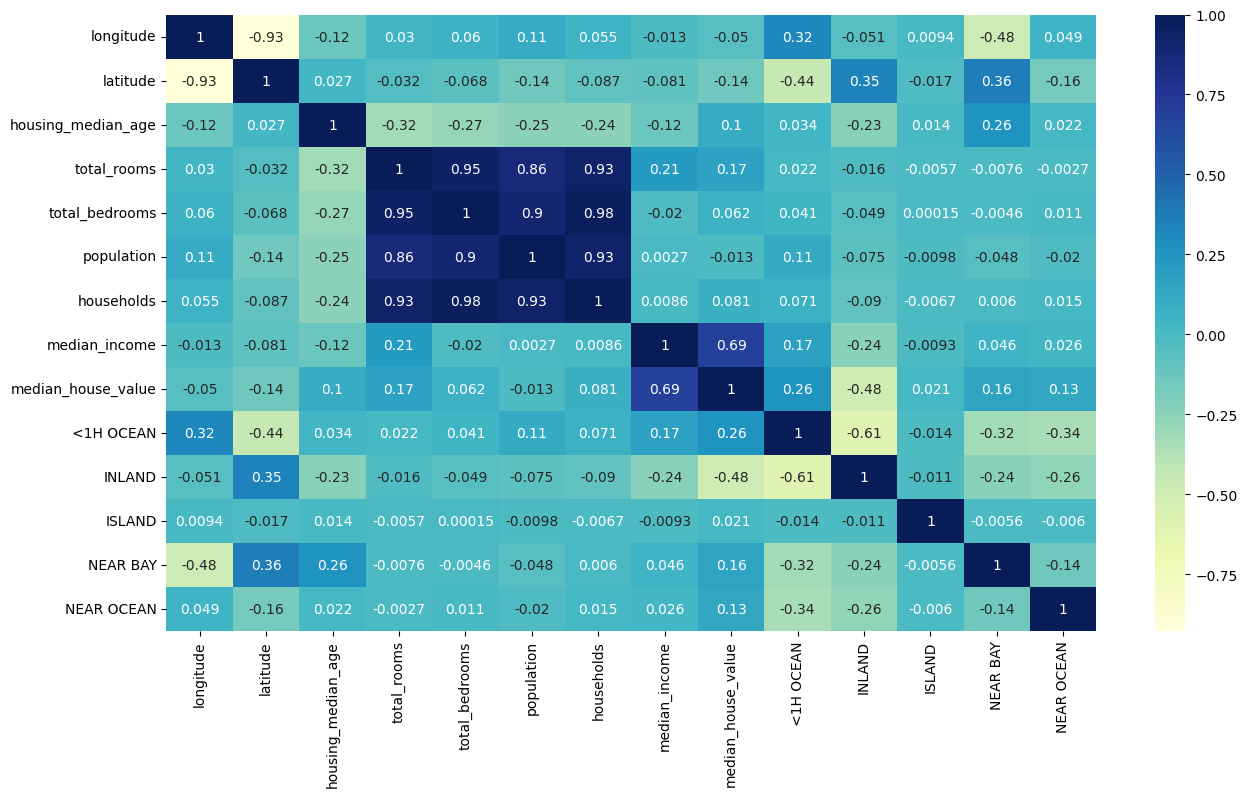

In [15]:
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")


In [16]:
plt.figure(figsize=(15,8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Axes: xlabel='latitude', ylabel='longitude'>

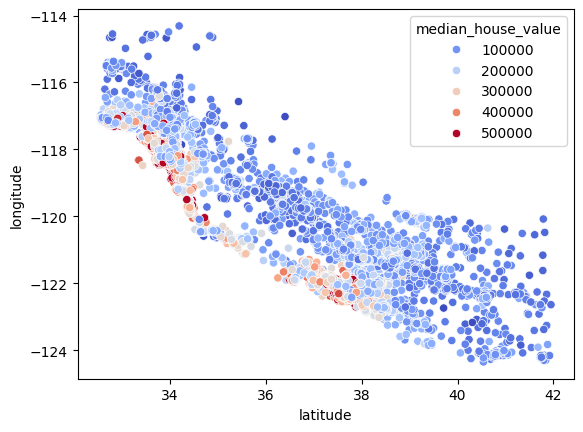

In [17]:
sns.scatterplot(x="latitude", y = "longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [18]:
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_room'] = train_data['total_rooms']/train_data['households']

<Axes: >

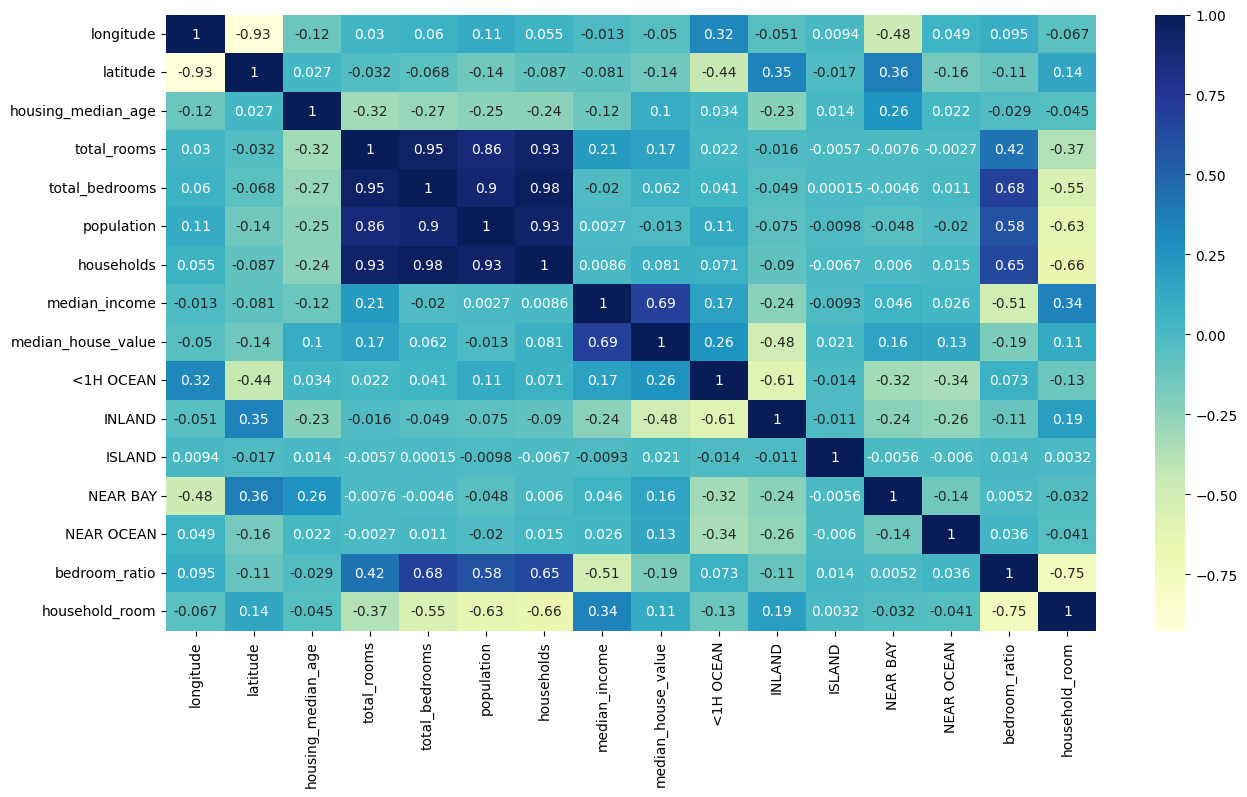

In [19]:
plt.figure(figsize = (15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value'] 
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()
ridge_model = Ridge(alpha = 1)
lasso_model = Lasso(alpha = 1.0)

reg.fit(X_train_s, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

C:\Users\ACER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.457775e+13, tolerance: 2.173e+10
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [21]:

test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(
    pd.get_dummies(test_data.ocean_proximity, dtype=int)
).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_room'] = test_data['total_rooms']/test_data['households']

In [22]:
X_test, y_test = train_data.drop(['median_house_value'], axis = 1), train_data['median_house_value']


In [23]:
X_test_s = scaler.transform(X_test)

In [24]:
reg.score(X_test_s, y_test)

0.6738838052407121

In [37]:
ridge_model.score(X_test, y_test)

0.6735941286571572

In [38]:
y_pred = ridge_model.predict(X_test)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test,y_pred)

MAE

47624.03215150415

In [39]:
RMSE

np.float64(65878.808736319)

In [40]:
r2

0.6735941286571572

In [43]:
y_pred_lasso = lasso_model.predict(X_test)
MAE_lasso = mean_absolute_error(y_test, y_pred_lasso)
RMSE_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test,y_pred_lasso)

In [44]:
MAE_lasso

47635.34284931804

In [45]:
RMSE_lasso

np.float64(65850.83442839804)

In [46]:
r2_lasso

0.6738712751287002